# Information Leakage in BB84 — Baseline Study

This notebook documents an **early exploratory stage** of the research developed for my Master's Thesis on information leakage in quantum key distribution. The main objective is to build a simple BB84 benchmark, quantify the information available to an eavesdropper, and connect the numerical experiment with the leakage-versus-gentleness framework introduced in *Measuring Quantum Information Leakage Under Detection Threat*.

The notebook is organized around two complementary tasks:

1. **Baseline BB84 simulation.** An ideal BB84 link is simulated under a simplified probabilistic intercept-resend attack. From the sifted data, I estimate the QBER and compare the information shared by Alice and Bob with the information obtained by Eve.
2. **Leakage-bound reconstruction.** I implement the optimization used to obtain a lower bound on information leakage as a function of the gentleness parameter $\alpha$, and reproduce the main qualitative comparison with several reference leakage values.

This is intentionally a **preliminary model**. The attack implemented here is based on random projective measurements and does not yet represent the more general POVM-based or cloning-based attacks developed later in the research.

> **Research context.** The results in this notebook were part of the exploratory work behind the thesis, but were not included in the final manuscript. They were useful for validating the numerical framework, establishing baseline leakage metrics, and motivating the more complete analyses presented in the subsequent notebooks.


## 1. Baseline BB84 simulation with probabilistic intercept-resend

I first construct an ideal BB84 exchange and introduce a simple eavesdropping model. For each transmitted qubit, Eve independently decides whether to intercept it with probability $p$. When she intercepts, she measures in a randomly chosen BB84 basis and prepares a new qubit from the measurement outcome before forwarding it to Bob.

This model is deliberately simple: it provides a controlled benchmark for observing how information gained by Eve translates into disturbance at Bob's side.


In [1]:

import numpy as np
import scipy as sp
import cvxpy as cp

from qutip import *
from qutip.qip.operations import hadamard_transform, snot # type: ignore
from qutip.measurement import measure_povm

import matplotlib.pyplot as plt
import math
from ortools.linear_solver import pywraplp

(CVXPY) Sep 30 07:16:41 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 30 07:16:41 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


### 1.1 Ideal-channel assumption

The first experiment excludes additional channel noise. Therefore, any QBER observed after sifting can be attributed to the interception process and finite-sample fluctuations rather than to an external depolarizing channel.


### 1.2 Alice: random bits, bases, and state preparation

Alice generates a random classical bit string together with an independent random choice of BB84 basis for each position. The bit-basis pairs are then encoded into the four BB84 states $|0\rangle$, $|1\rangle$, $|+\rangle$, and $|-\rangle$.


In [2]:
def generate_alice_bits_and_bases(num_bits):
    """
    Generates Alice's random bits and a random basis for each bit.
    """
    # Generate random bits (0 or 1)
    alice_bits = np.random.randint(2, size=num_bits)
    # Generate random basis (0 for Z basis, 1 for X basis)
    alice_basis = np.random.randint(2, size=num_bits)
    
    return alice_bits, alice_basis


# Parameters for the simulation
input_bits = 125
n_bits = input_bits * 4
p = 0.1  # Probability that Eve intercepts a qubit

# Generate Alice's bits and bases
alice_bits, alice_basis = generate_alice_bits_and_bases(n_bits)

print(f"Alice's bits:\n{alice_bits}")
print(f"Alice's basis:\n{alice_basis}")

Alice's bits:
[1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 1 1
 0 0 1 1 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1
 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 1 1 0 0
 0 1 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 0 1
 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0
 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 0
 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0
 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 0 0 1 0
 0 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 0 1 0 1 1 1
 1 1 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 0
 0 0 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1 1
 1 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 1 0 1 0
 0 0 1 0 1 

For this baseline experiment, the states are encoded directly as pure BB84 states. In particular, no depolarizing channel is inserted between Alice and Eve, so the effect of Eve's intervention can be isolated from other sources of disturbance.


In [3]:
import qutip
print(qutip.__version__)

5.2.3


In [4]:
def create_qubits(bits_vector, bases_vector):
    """
    Encodes classical bits into quantum states based on the chosen basis.
    
    - Z basis (0) maps 0 -> |0> and 1 -> |1>
    - X basis (1) maps 0 -> |+> and 1 -> |->
    
    Args:
        bits (np.ndarray): An array of classical bits (0 or 1).
        bases (np.ndarray): An array of bases (0 for Z, 1 for X).
        
    Returns:
        list: A list of QuTiP Qobj representing the qubits.
    """
    qubits = []
    H_matrix = (1 / np.sqrt(2)) * np.array([[1, 1],
                                            [1, -1]])
    H_gate = Qobj(H_matrix)
    for bit, basis_val in zip(bits_vector, bases_vector):
        if bit == 0:
            state = basis(2, 0)  # |0> state
        else:
            state = basis(2, 1)  # |1> state
        
        # If the basis is X (1), apply the Hadamard gate
        if basis_val == 1:
            state = H_gate * state # snot() is the single-qubit Hadamard gate
        
        qubits.append(state)
        
    return qubits


# Create the qubits that Alice will send
alice_qubits = create_qubits(alice_bits, alice_basis)
print("Alice has prepared and sent the qubits.")
print(alice_qubits[:5])  # Print the first 5 qubits for verification


Alice has prepared and sent the qubits.
[Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]], Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]], Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]], Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]], Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]]


### 1.3 Eve: probabilistic intercept-resend attack

Eve intercepts each qubit independently with probability $p$. If she intercepts, she chooses either the $Z$ or $X$ basis at random, performs the corresponding projective measurement, and resends a state consistent with the observed outcome. Otherwise, the original qubit is forwarded unchanged.

This is not yet the general gentle-measurement model; it is a baseline attack used to establish the expected relationship between eavesdropping, QBER, and classical information leakage.


In [5]:
def eves_interception(qubit, p):
    """
    Simulates Eve's gentle eavesdropping on a single qubit.
    
    With probability `p`, Eve measures the qubit in a random basis and resends.
    With probability `1-p`, she lets the qubit pass undisturbed.
    
    Args:
        qubit (Qobj): The qubit sent by Alice.
        p (float): The probability of Eve performing a measurement.
        
    Returns:
        tuple: A tuple containing the modified qubit (Qobj) and the
        result of Eve's measurement (int or None).
    """
    eve_basis = np.random.randint(2)
    eve_measurement = None
    H_matrix = (1 / np.sqrt(2)) * np.array([[1, 1],
                                            [1, -1]])
    H_gate = Qobj(H_matrix)
    # Simulate Eve's gentle POVM
    if np.random.rand() < p:
        # Eve measures the qubit in her random basis
        if eve_basis == 0: # Z basis measurement
            z_projectors = [ket2dm(basis(2, 0)), ket2dm(basis(2, 1))]
            measured_result, _ = measure_povm(qubit, z_projectors)
            eve_measurement = measured_result
            # Eve prepares a new qubit based on her measurement result and sends it to Bob
            resend_qubit = create_qubits([measured_result], [eve_basis])[0]
        else: # X basis measurement
            x_projectors = [ket2dm(H_gate * basis(2, 0)), ket2dm(snot() * basis(2, 1))]
            measured_result, _ = measure_povm(qubit, x_projectors)
            eve_measurement = measured_result
            # Eve prepares a new qubit based on her measurement result and sends it to Bob
            resend_qubit = create_qubits([measured_result], [eve_basis])[0]
    else:
        resend_qubit = qubit
        
    return resend_qubit, eve_measurement

eves_qubits_to_bob = []
eves_measurements = []
print(f"\nEve has intercepted with a probability p = {p} and resent the qubits.")
for q in alice_qubits:
    resend_q, eve_m = eves_interception(q, p)
    eves_qubits_to_bob.append(resend_q)
    eves_measurements.append(eve_m)



Eve has intercepted with a probability p = 0.1 and resent the qubits.


### 1.4 Bob: random-basis measurement

Bob measures every received qubit in an independently selected $Z$ or $X$ basis. At this stage, his raw outcomes include both compatible and incompatible basis choices relative to Alice's preparation.


In [6]:
def VN_measurement(qubits, bases):
    """
    Measures a list of qubits in the specified basis.
    
    Args:
        qubits (list): A list of QuTiP Qobj representing the qubits.
        bases (np.ndarray): An array of bases (0 for Z, 1 for X) for measurement.
        
    Returns:
        list: A list of classical bits (0 or 1) representing the measurement results.
    """
    measurements = []
    measured_states = []
    # Define the measurement projectors for Z and X bases
    z_projectors = [ket2dm(basis(2, 0)), ket2dm(basis(2, 1))]
    x_projectors = [ket2dm(snot() * basis(2, 0)), ket2dm(snot() * basis(2, 1))]
    
    for qubit, basis_val in zip(qubits, bases):
        if basis_val == 0:  # Z basis measurement
            measured_result, measured_state = measure_povm(qubit, z_projectors)
        else:  # X basis measurement
            measured_result, measured_state = measure_povm(qubit, x_projectors)
        
        measurements.append(measured_result)
            
            
    return measurements







# --- Bob's Part ---
print("\nBob: I received the qubits")
bob_basis = np.random.randint(2, size=n_bits)
print(f"Bob's basis:\n{bob_basis}")

bob_measurements = VN_measurement(eves_qubits_to_bob, bob_basis)
print(f"Bob's measurements:\n{bob_measurements}")


Bob: I received the qubits
Bob's basis:
[0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1 0 0 0
 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 0 0 0 0 0
 1 0 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1
 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 1
 0 1 0 1 0 0 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1
 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1
 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 1
 1 1 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0
 0 0 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0
 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 

### 1.5 Basis reconciliation and sifting

Alice and Bob publicly reveal only the bases used for each transmission. Positions in which their bases disagree are discarded, leaving the sifted keys. Eve's recorded outcomes are filtered using the same retained positions so that her information can be compared against the sifted data.


In [7]:
print("Alice: I will announce my basis")
print(f"Alice's basis:\n{alice_basis}\n\n")
print("Bob: I will announce my basis")
print(f"Bob's basis:\n{bob_basis}")

Alice: I will announce my basis
Alice's basis:
[0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0
 0 1 1 0 0 0 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 1 0 0 0
 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1
 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1
 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 0 0 0
 0 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0
 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1
 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0
 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0
 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 

In [8]:
def match_bases(a_bases: list[int], b_bases: list[int], message: list[int]) -> list[int]:
    """
    Compare the bases used by Alice and Bob.
    If they match, keep the bit from the message.
    If they don't match, discard the bit.
    """
    message_clean = []
    
    n = len(a_bases)
    for q in range(n):
        if a_bases[q] == b_bases[q]:
            # If both bases match, keep the bit.
            message_clean.append(message[q])        
    return message_clean

alice_key = match_bases(alice_basis, bob_basis, alice_bits)
bob_key = match_bases(alice_basis, bob_basis, bob_measurements)
eve_sifted_key = match_bases(alice_basis, bob_basis, eves_measurements)
print(f"Alice's key:\n{alice_key}")  #TO SHOWCASE
print(f"Bob's key:\n{bob_key}\n\n")  #TO SHOWCASE

print(f"Length of the keys: {len(alice_key)}")

Alice's key:
[np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1)

### 1.6 Parameter-estimation sample

A subset of the sifted key is publicly compared to estimate the error rate of the quantum channel. These disclosed positions are removed from the candidate secret key. Eve's sifted record is partitioned using the same indices so that the remaining datasets stay aligned for the later leakage calculation.


In [9]:
def sample_bits(bits, selection):
    """
    Takes a sample from a list of bits based on a list of indices
    and returns both the sample and the remaining bits.
    
    Args:
        bits (list): The list of bits to sample from.
        selection (list): The list of indices to select.
        
    Returns:
        tuple: A tuple containing the sampled bits and the remaining bits.
    """
    sample = [bits[i] for i in selection]
    
    # Create a new list for the remaining bits, excluding the sampled indices.
    selection_set = set(selection)
    remaining_bits = [bits[i] for i in range(len(bits)) if i not in selection_set]
    
    return sample, remaining_bits



print("Alice: I will announce my key")
sample_size = len(alice_key) // 2  #Sample half of the key, should be of size n_bits
bit_selection = np.random.randint(len(alice_key), size=sample_size)
alice_sample, alice_key = sample_bits(alice_key, bit_selection)
print(f"Bit's selected for sampling:\n{bit_selection}")
print(f"Alice's sample:\n{alice_sample}\n\n")  #TO SHOWCASE


print("Bob: I will announce my key")
bob_sample, bob_key= sample_bits(bob_key, bit_selection)
print(f"Bob's sample:\n{bob_sample}\n\n")   #TO SHOWCASE




print("Length of the samples: ", len(alice_sample))
print("Length of the keys: ", len(alice_key))

# EVE ALSO SIFTS HER KEY USING THE SAME INDICES AS ALICE AND BOB
eve_sample, eve_sifted_key = sample_bits(eve_sifted_key, bit_selection)
print("Length of Eve's sample: ", len(eve_sample))
print("Length of Eve's sifted key: ", len(eve_sifted_key))
print(f"Eve's sample:\n{eve_sample}\n\n")   #TO SHOW




Alice: I will announce my key
Bit's selected for sampling:
[192 182  44 148  69 206 127  81  86 215 198 165   9 214   4 191  87 192
 175 204  72 209 226  55  62 178  32  44  25 147  61  58 159  42   3 113
 146 224 167 202 213  77 191 174 112 199  54 194  91 189 140  26  63 118
 231  18  87 232  21 116  91  42 195 157  53 184  81 194 104 222 206  88
  27  70 197  30  80  31  95 235 108 105 106  23  80 193   8   1 217  70
 181  23 138 171  47 196  36 223  90 165 221 100 219  93 110 161 227   7
 143 192 128  70  16  26 157 212 149  16]
Alice's sample:
[np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np

### 1.7 Estimating the QBER

The disturbance introduced during transmission is summarized through the **Quantum Bit Error Rate (QBER)**, computed as the fraction of mismatches between Alice's and Bob's publicly compared sample bits.


In [10]:
#GUESS THE BER
def guess_ber(alice_sample: list[int], bob_sample: list[int]) -> float:
    """
    Calculate the bit error rate (BER) between Alice's and Bob's samples.
    The function takes two lists of bits and returns the BER as a float.
    """
    n = len(alice_sample)
    errors = 0
    for i in range(n):
        if alice_sample[i] != bob_sample[i]:
            errors += 1
    ber = errors / n
    return ber

ber = guess_ber(alice_sample, bob_sample)
print(f"Bit error rate: {ber:.2%}")


Bit error rate: 2.54%


## 2. Empirical information leakage

With the sifted data available, I use classical mutual information as a first leakage metric. This provides a simple baseline before introducing the generalized leakage measures used later in the thesis.

Two quantities are considered:

- $I(A;E)$, estimated directly from the empirical joint distribution of Alice's bits and Eve's outcomes.
- $I(A;B)$, approximated from the measured QBER by modelling the Alice-Bob link as a binary symmetric channel.


### 2.1 Alice–Eve mutual information

Eve may either obtain a binary result or not measure a particular qubit. I therefore represent her record with three possible outcomes: `0`, `1`, and `no measurement`. The joint empirical distribution $P(A,E)$ is then used to calculate the Shannon mutual information between Alice and Eve.


In [11]:
def calculate_total_leakage(alice_bits, eves_measurements):
    """
    Calculates the total classical information leakage to Eve across the
    entire key, using data from a simulation.

    Args:
        alice_bits (np.ndarray): Alice's original bits for the full key.
        eves_measurements (list): Eve's measurement results (can be None).

    Returns:
        float: The total mutual information leakage in bits.
    """
    total_key_length = len(alice_bits)

    # 1. Create a joint dataset of Alice's bits and Eve's 'measured' results.
    simulated_eve_outcomes = []
    for m in eves_measurements:
        if m is None:
            simulated_eve_outcomes.append(2) # Represents 'no measurement'
        else:
            simulated_eve_outcomes.append(int(m))

    # 2. Calculate the joint probability distribution P(A, E) for the entire key
    joint_prob = np.zeros((2, 3))
    for a, e in zip(alice_bits, simulated_eve_outcomes):
        joint_prob[int(a), e] += 1
    joint_prob /= total_key_length
    
    # 3. Calculate marginal probabilities P(A) and P(E)
    prob_a = np.sum(joint_prob, axis=1) # P(A=0), P(A=1)
    prob_e = np.sum(joint_prob, axis=0) # P(E=0), P(E=1), P(E='none')
    
    # 4. Calculate mutual information across all outcomes
    mutual_information = 0
    for i in range(2): # Alice's bits
        for j in range(3): # Eve's outcomes
            if joint_prob[i, j] > 0:
                mutual_information += joint_prob[i, j] * math.log2(joint_prob[i, j] / (prob_a[i] * prob_e[j]))
    
    return mutual_information

total_leakage = calculate_total_leakage(alice_bits, eves_measurements)
total_leakage_sifted = calculate_total_leakage(alice_key, eve_sifted_key)
print(f"Total information leakage across the entire key: {total_leakage:.4f} bits")
print(f"Total information leakage across the sifted key: {total_leakage_sifted:.4f} bits")

Total information leakage across the entire key: 0.0125 bits
Total information leakage across the sifted key: 0.0106 bits


### 2.2 Alice–Bob mutual information from QBER

For the Alice-Bob link, I use the binary-symmetric-channel expression

$$
I(A;B)=1-h_2(Q),
$$

where $Q$ is the estimated QBER and $h_2$ is the binary entropy function. This gives a compact information-theoretic interpretation of the disturbance observed in the sifted key.


In [12]:
def calculate_mutual_information_ber(ber):
    """
    Calculates the mutual information for a binary symmetric channel
    from the bit error rate (BER).

    Args:
        ber (float): The bit error rate (p), a value between 0 and 1.

    Returns:
        float: The mutual information in bits.
    """
    if not 0 <= ber <= 1:
        raise ValueError("BER must be between 0 and 1.")

    # Handle edge cases where log(0) is undefined
    if ber == 0 or ber == 1:
        return 1.0 if ber == 0 else 0.0

    # Binary entropy function
    h_p = -ber * math.log2(ber) - (1 - ber) * math.log2(1 - ber)
    
    # Mutual information formula
    mutual_information = 1 - h_p
    
    return mutual_information


mutual_info_ab = calculate_mutual_information_ber(ber)
print(f"Mutual Information between Alice and Bob (based on BER): {mutual_info_ab:.4f} bits")


Mutual Information between Alice and Bob (based on BER): 0.8291 bits


### 2.3 Encapsulating the baseline experiment

The complete sequence is wrapped into a single function so that the interception probability can later be varied systematically. For each run, the function regenerates Alice's states, applies Eve's probabilistic interception, performs Bob's measurement and sifting, estimates the QBER, and returns the corresponding information quantities.

Because this is a Monte Carlo simulation, individual runs fluctuate with the randomly generated bits, bases, and interception events.


In [13]:
def BB84_intercepted_simplified_ideal(n_bits, p):
    """
    Simulates a simplified BB84 protocol where Eve intercepts and measures every qubit.
    The parameter 'p' represents the probability that Eve chooses a basis that is
    different from Alice's basis for her measurement.

    Args:
        n_bits (int): The number of bits in the initial key.
        p (float): The probability that Eve uses a mismatched basis.

    Returns:
        tuple: A tuple containing the QBER, I(A:E), and I(B:E).
    """
    alice_bits, alice_basis = generate_alice_bits_and_bases(n_bits)
    alice_qubits = create_qubits(alice_bits, alice_basis)  # <-- Add this line

    # Eve's gentle interception
    eves_qubits_to_bob = []
    eves_measurements = []
    for q in alice_qubits:  # <-- Now uses the correct local qubits
        resend_q, eve_m = eves_interception(q, p)
        eves_qubits_to_bob.append(resend_q)
        eves_measurements.append(eve_m)

    # 3. Eve re-prepares the qubits and sends them to Bob
    # 4. Bob receives the qubits and measures with his own random bases
    # --- Bob's Part ---
    bob_basis = np.random.randint(2, size=n_bits)
    bob_measurements = VN_measurement(eves_qubits_to_bob, bob_basis)


    # 5. Public discussion: Alice and Bob compare bases
    alice_key = match_bases(alice_basis, bob_basis, alice_bits)
    bob_key = match_bases(alice_basis, bob_basis, bob_measurements)
    eve_sifted_key = match_bases(alice_basis, bob_basis, eves_measurements)

    # Handle the case where the sifted key is empty
    sample_size = len(alice_key) // 2  #Sample half of the key, should be of size n_bits
    bit_selection = np.random.randint(len(alice_key), size=sample_size)
    
    alice_sample, alice_key = sample_bits(alice_key, bit_selection)
    bob_sample, bob_key= sample_bits(bob_key, bit_selection)
    eve_sample, eve_sifted_key = sample_bits(eve_sifted_key, bit_selection)
    
    
    # 6. Calculate QBER (Quantum Bit Error Rate)
    qber = guess_ber(alice_sample, bob_sample)

    # 7. Calculate Mutual Informations
    # Mutual information between Alice's sifted key and Eve's measurements
    total_leakage = calculate_total_leakage(alice_bits, eves_measurements)
    total_leakage_sifted = calculate_total_leakage(alice_key, eve_sifted_key)
    

    # Mutual information between Bob's sifted key and Eve's measurements
    mutual_info_ab = calculate_mutual_information_ber(qber)

    return qber, total_leakage, total_leakage_sifted, mutual_info_ab


## 3. Lower bound on $\alpha$-gentle information leakage

The second part of the notebook connects the simulation with the theoretical leakage framework from the reference study. The objective is to evaluate a lower bound $L^{\alpha}$ as the admissible disturbance, represented by the gentleness parameter $\alpha$, is varied.

### 3.1 Optimization over the cloning-region parameters

For each value of $\alpha$, the following routine solves the constrained optimization problem used in the bound. The variables $p_1$ and $p_2$ are restricted by the qubit cloning-region inequality, while $p_1 \leq 2\alpha$ imposes the corresponding disturbance constraint for the pure-qubit case.

The optimization minimizes $p_2$; the resulting $p_2^{\star}$ is then substituted into the leakage expression in the next step.


In [14]:
def solve_lower_bound_p2(alpha_value):
    p1 = cp.Variable()
    p2 = cp.Variable()

    constraints = [
        p1 >= 0, p1 <= 1,
        p2 >= 0, p2 <= 1,

        # Correct BB84 pure-qubit disturbance constraint:
        # ||I/2 - rho||_tr = 1/2, so p1 <= alpha / (1/2) = 2 alpha
        p1 <= 2 * alpha_value,

        # Qubit cloning-region constraint
        3*(p1 - p2)**2 - 6*p1 - 6*p2 + 3 <= 0
    ]

    prob = cp.Problem(cp.Minimize(p2), constraints)
    prob.solve()

    return p2.value

### 3.2 Evaluating the leakage bound

Once $p_2^{\star}$ has been obtained, the lower-bound expression is evaluated numerically. For the binary setting considered here, the quantity $Q$ appearing in the expression is fixed to one bit.


In [15]:
def calculate_lower_bound_leakage(p2_star):

    Q = 1   #Calculated in the document
    argument = p2_star + (1 - p2_star) * (2**Q)   
    
    if argument > 0:
        return math.log2(argument)
    else:
        # Should not happen for 0 <= p2* <= 1
        return -float('inf')



### 3.3 Leakage as a function of gentleness

The optimization is repeated over a logarithmic range of $\alpha$ values. Plotting $L^{\alpha}$ against $\alpha$ makes the central trade-off visible: allowing a larger disturbance enlarges the amount of information that can be leaked while remaining compatible with the imposed constraint.


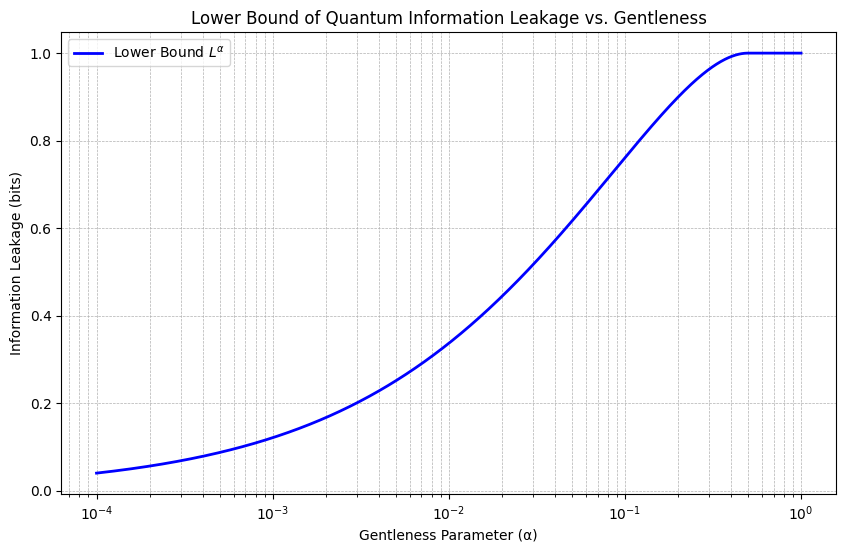

In [16]:
def plot_lower_bound():
    """
    Generates data and plots the lower bound curve for gentle leakage.
    """
    alpha_values = np.logspace(-4, 0, 1000)
    L_alpha_values = []
    
    for alpha in alpha_values:
        p2_star = solve_lower_bound_p2(alpha)
        
        L_alpha = calculate_lower_bound_leakage(p2_star)
        L_alpha_values.append(L_alpha)
    
    plt.figure(figsize=(10, 6))
    plt.plot(alpha_values, L_alpha_values, label='Lower Bound $L^{\\alpha}$', color='blue', linewidth=2)
    
    plt.xscale('log')
    

    plt.title('Lower Bound of Quantum Information Leakage vs. Gentleness')
    plt.xlabel('Gentleness Parameter (α)')
    plt.ylabel('Information Leakage (bits)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

plot_lower_bound()

## 4. Reproducing the reference leakage comparison

As a final validation step, I recreate the main qualitative comparison used in the reference analysis. The optimized lower-bound curve is plotted together with the benchmark leakage values $I(X;W_1)$, $I(X;W_2)$ and their order-$\infty$ counterparts.

Before generating the complete figure, the optimization is evaluated at a single example value, $\alpha=0.4$, as a simple numerical sanity check. The purpose of this section is **implementation validation and interpretation**, rather than presenting a new result of the thesis.


In [17]:
example_alpha = 0.4
p2_star_example = solve_lower_bound_p2(example_alpha)
L_alpha_example = calculate_lower_bound_leakage(p2_star_example)
print(f"For α = {example_alpha}, the optimal p2* is approximately {p2_star_example:.4f} and the lower bound L^α is approximately {L_alpha_example:.4f} bits.")

For α = 0.4, the optimal p2* is approximately 0.0111 and the lower bound L^α is approximately 0.9919 bits.


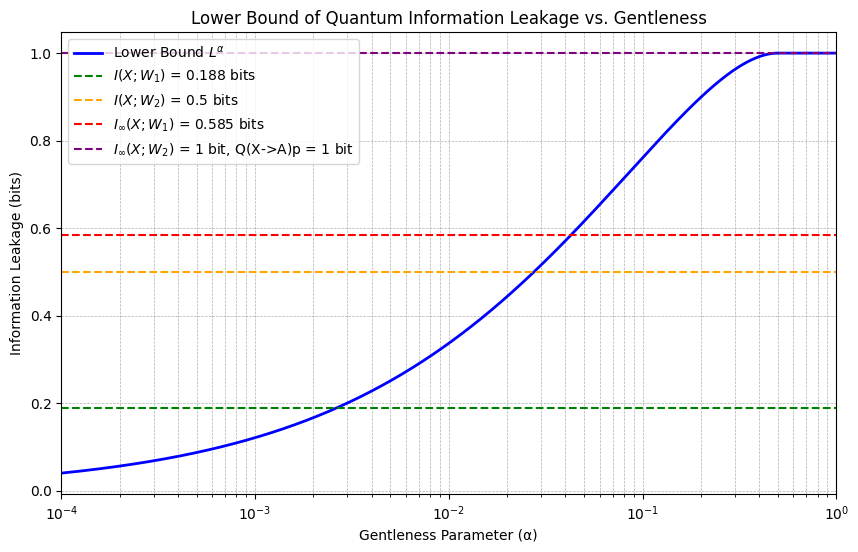

In [18]:
def plot_whole_graph():
    """
    Generates data and plots the lower bound curve for gentle leakage.
    """
    alpha_values = np.logspace(-4, 0, 1000)
    L_alpha_values = []
    
    for alpha in alpha_values:
        p2_star = solve_lower_bound_p2(alpha)
        

        L_alpha = calculate_lower_bound_leakage(p2_star)
        L_alpha_values.append(L_alpha)
    

    plt.figure(figsize=(10, 6))
    plt.plot(alpha_values, L_alpha_values, label='Lower Bound $L^{\\alpha}$', color='blue', linewidth=2)


    plt.axhline(y=0.188, color='green', linestyle='--', label='$I(X;W_{1})$ = 0.188 bits')
    plt.axhline(y=0.5, color='orange', linestyle='--', label='$I(X;W_{2})$ = 0.5 bits')
    plt.axhline(y=0.585, color='red', linestyle='--', label='$I_{\\infty}(X;W_{1})$ = 0.585 bits')
    

    plt.axhline(y=1.0, color='purple', linestyle='--', label='$I_{\\infty}(X;W_{2})$ = 1 bit, Q(X->A)p = 1 bit')


    plt.xscale('log')
    plt.xlim(10**-4, 10**0)
    

    plt.title('Lower Bound of Quantum Information Leakage vs. Gentleness')
    plt.xlabel('Gentleness Parameter (α)')
    plt.ylabel('Information Leakage (bits)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()


plot_whole_graph()

## Conclusion

This notebook establishes the first numerical baseline for the information-leakage study:

- An end-to-end BB84 exchange was implemented under an ideal channel and a simplified probabilistic intercept-resend attack.
- The resulting disturbance was quantified through the QBER.
- Classical mutual information was used to compare the Alice-Bob correlation with the information empirically available to Eve.
- The constrained optimization for the $\alpha$-gentle leakage lower bound was implemented and evaluated over a range of disturbance levels.
- The resulting curve was compared with the reference leakage values used to reproduce the qualitative behaviour reported in the motivating work.

The eavesdropping strategy is intentionally simplified, the results are subject to finite-sample randomness, and the baseline simulation excludes independent channel noise.

These limitations motivate the next stage of the research: replacing the simple intercept-resend model with explicitly designed measurement strategies and studying the information-disturbance trade-off more directly. 
